# PROCESS

## 1. Esplorazione dei Dati (EDA)
Il primo passo fondamentale è caricare il file train_dropout.csv ed esplorarne il contenuto
.

Analisi delle feature: Identifica quali colonne sono numeriche (es. età, voti) e quali categoriche (es. corso di studi, genere)
.

Gestione dei valori mancanti: Verifica se ci sono dei NaN. Se sono pochi (inferiori al 5%), potresti decidere di eliminarli, altrimenti dovrai ricorrere all'imputazione (media per dati numerici, moda per quelli categorici)
.

Analisi del Target: Controlla se le classi "Dropout" e "Graduate" sono bilanciate. Se una classe è molto più frequente dell'altra, dovrai adottare strategie specifiche per dataset sbilanciati
.

## 2. Preprocessing e Feature Engineering
I dati grezzi raramente sono pronti per il modello
.

Codifica delle Categoriche: Trasforma le variabili testuali in numeri usando tecniche come l'One-Hot Encoding (creando colonne 0/1)
.

Scaling: Per molti algoritmi (come kNN o Regressione Logistica), è essenziale portare tutte le variabili sulla stessa scala (es. media 0 e deviazione standard 1) usando uno StandardScaler
.

Creazione di Nuove Feature: Segui il suggerimento del cliente! Calcola, ad esempio, il trend degli esami (esami superati nel 2° semestre meno quelli del 1°).
Una variazione negativa potrebbe essere un forte segnale di rischio
.

## 3. Definizione della Baseline
Prima di usare modelli complessi, stabilisci un punto di riferimento usando un modello "Dummy" (che predice sempre la classe più frequente)
.
 Se il tuo modello sofisticato non batte la baseline, c'è un errore nel processo
.
## 4. Il Processo di Model Selection
Questa è la fase cruciale per vincere l'Hackathon.
Data Splitting: Dividi il tuo dataset di train in Training Set (per allenare) e Validation Set (per scegliere i parametri)
.
 Non usare il file di test finale per questa fase per evitare il "data leakage"
.
Scelta degli Algoritmi: Testa diversi modelli come la Regressione Logistica (veloce e interpretabile)
, i Decision Trees
, o modelli ensemble più potenti come Random Forest
 e XGBoost
.
Hyperparameter Tuning: Ogni modello ha dei parametri (es. profondità dell'albero o numero di vicini in kNN) che vanno ottimizzati
.
 Usa strumenti come la Grid Search per testare sistematicamente diverse combinazioni
.
Cross-Validation: Per una stima più robusta, usa la K-Fold Cross-Validation, dividendo i dati in più blocchi e ruotando quelli di test/allenamento
.

## 5. Gestione dello Sbilanciamento (Imbalance)
Poiché l'obiettivo è massimizzare l'F1-score Macro, devi prestare molta attenzione alla classe minoritaria ("Dropout")
.

Strategie: Puoi usare tecniche di Oversampling (duplicando i record della classe rara) o impostare il parametro class_weight='balanced' in modelli come Random Forest per penalizzare maggiormente gli errori sui dropout
.

## 6. Valutazione e Interpretazione
Metriche: Non guardare solo l'accuracy. Analizza il Classification Report concentrandoti sulla macro-average dell'F1-score
.

Interpretazione: Prima di consegnare, usa la Feature Importance (per Random Forest/XGBoost) o i coefficienti (per la Regressione Logistica) per identificare le 3 variabili che influenzano di più l'abbandono
.

## 7. Predizione Finale e Consegna
Una volta scelto il modello migliore sul validation set, riaddestralo su tutto il dataset train_dropout.csv e usalo per produrre le predizioni sul file test_dropout.csv
.
 Genera il file CSV finale assicurandoti che contenga esattamente 726 righe con le etichette predette.

Consiglio finale: Lavorate in coppia per confrontare diverse strategie di Feature Engineering; spesso una buona variabile creata a mano vale più di un algoritmo complesso
. Buon lavoro!

# Previsione Abbandono Universitario

## 1. Preparazione del dataset
Importiamo le librerie necessarie per la creazione del modello.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold, GridSearchCV
)
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

## 1.2. Esplorazione del Dataset

Incorporiamo il file train_dropout.csv per vedere le colonne ed esplorare i dati.

In [3]:
df = pd.read_csv('./CSV/train_dropout.csv')

In [4]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,44,1,9003,1,39,150.0,1,19,37,...,0,6,7,6,13.833333,0,13.9,-0.3,0.79,Graduate
1,2,39,1,9991,0,1,135.0,1,34,34,...,0,5,5,0,0.000000,0,7.6,2.6,0.32,Dropout
2,1,1,1,9238,1,1,121.0,1,1,1,...,0,6,7,6,12.142857,0,11.1,0.6,2.02,Graduate
3,1,1,4,9500,1,1,135.0,1,37,37,...,0,8,8,7,13.381429,0,10.8,1.4,1.74,Graduate
4,2,39,1,8014,0,12,110.0,1,34,34,...,2,6,9,6,12.500000,0,7.6,2.6,0.32,Graduate


In [5]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,...,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000
mean,1.185606,18.415289,1.746901,8848.062328,0.888430,4.621212,132.986191,1.755165,20.032369,22.588843,...,0.126033,0.585744,6.288912,7.753099,4.505854,10.014150,0.133264,11.660537,1.227789,0.001009
std,0.613028,17.335091,1.329204,2077.051948,0.314891,10.162905,13.176359,6.206597,15.585075,15.263052,...,0.666059,2.011391,2.252767,3.975813,3.158457,5.499942,0.717246,2.668650,1.380022,2.252360
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.500000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.333333,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.500000,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,6.000000,9991.000000,1.000000,43.000000,190.000000,105.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2904 entries, 0 to 2903
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  2904 non-null   int64  
 1   Application mode                                2904 non-null   int64  
 2   Application order                               2904 non-null   int64  
 3   Course                                          2904 non-null   int64  
 4   Daytime/evening attendance	                     2904 non-null   int64  
 5   Previous qualification                          2904 non-null   int64  
 6   Previous qualification (grade)                  2904 non-null   float64
 7   Nacionality                                     2904 non-null   int64  
 8   Mother's qualification                          2904 non-null   int64  
 9   Father's qualification                   

In [8]:
#Gestione dei valori mancanti:
valori_nun = df.isnull().sum()
print(valori_nun)

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

/tmp/ipykernel_17315/958896609.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Target", palette="Set2")


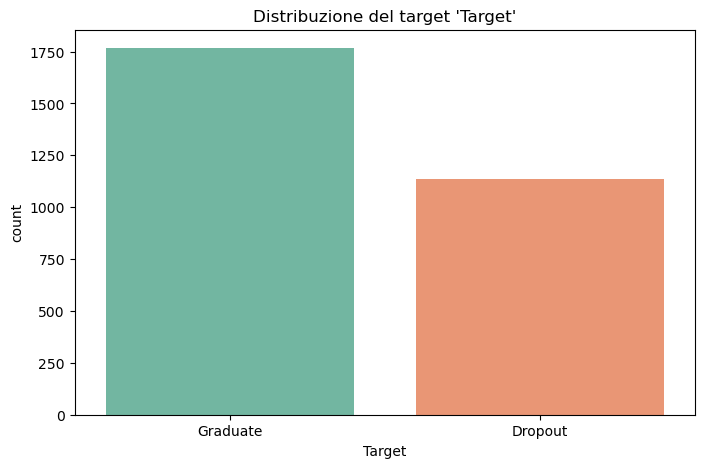

In [11]:
#Analisi del target:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Target", palette="Set2")
plt.title("Distribuzione del target 'Target'")
plt.show()

## 2. Preprocessing e Feature Engineering

In [17]:
# Codifica delle variabili categoriche:
X = pd.get_dummies(df.drop("Target", axis=1), drop_first=True)
y = df["Target"].map({"Graduate": 1, "Dropout": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [18]:
# Scaling con StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Creazione di Nuove Feature:
df["Variazione Neg Esami"] = df[""] - df[""]